# Trabajo Práctico N.° 2 — Análisis de Series Temporales

## 07b — Tratamiento de datos: atípicos, faltantes y modelos de espacio de estados

**Por qué este notebook va acá y no antes:** `01`-`07` (TP1) ya están cerrados con resultados calculados (SARIMA con grid search costoso, VAR con selección de orden hasta lag=48) que no se van a alterar. Este notebook trata atípicos y huecos que quedaron sin tratamiento explícito en el EDA original (`03_eda.ipynb` sólo hacía `isna().sum()`, sin detección de atípicos ni política documentada de imputación) y produce un dataset tratado nuevo — `serie_california_tratada.csv` — que usarán `08` en adelante. **No se toca `serie_california.csv` ni se recalculan `01`-`07`.**

**Contenido:**
1. Detección de atípicos (comparación contra la misma hora del día en una ventana de ±30 días — evita confundir el ciclo diario de ozono/radiación con anomalías).
2. Tratamiento: corrección sólo de atípicos aislados (≤3 horas seguidas, interpolación lineal); los sostenidos (>3h) se documentan como eventos reales (episodios de contaminación, olas de calor) y NO se tocan.
3. Huecos temporales remanentes (~48h/año que quedaron del criterio ya aplicado en `02_limpieza.ipynb`): se resuelven una sola vez acá (antes se parcheaba por separado en cada notebook de `08`-`12` — ver `feedback_dl_libs_compat` en la memoria del proyecto).
4. Modelos de espacio de estados (`UnobservedComponents`) y suavizado exponencial explícitamente formulado como modelo de espacio de estados (`ETSModel`) — puntos de la consigna no cubiertos todavía, reutilizando `statsmodels` (ya instalado).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

datos = pd.read_csv(
    PROJECT_ROOT / "data/processed/serie_california.csv",
    index_col="datetime_utc",
    parse_dates=True,
)
datos.index = datos.index.tz_localize(None)

print(f"Filas: {len(datos):,} | Rango: {datos.index.min()} a {datos.index.max()}")
print(datos.isna().sum())

Filas: 239,078 | Rango: 1998-01-01 08:00:00 a 2025-08-27 09:00:00
ozono_ppm            0
temperatura_c        0
radiacion_ghi_wm2    0
dtype: int64


## 1. Detección de atípicos

`isna().sum()` da cero en las tres columnas (ninguna fila tiene huecos internos), pero eso no dice nada sobre atípicos ni sobre huecos en el **índice temporal** (fechas enteras faltantes) — dos cosas distintas que se tratan por separado abajo.

**Método:** para cada observación se compara su valor contra la mediana y el MAD (desviación absoluta mediana, más robusto que desvío estándar frente a la propia presencia de atípicos) calculados **sobre la misma hora del día**, en una ventana móvil de ±30 días. Comparar sólo contra la misma hora evita el problema de un IQR/Z-score global: el ciclo diario de ozono y sobre todo de radiación (cero de noche, pico al mediodía) haría que un valor de radiación al mediodía se vea como "atípico" frente a valores nocturnos, cuando en realidad es la variación normal esperada. Umbral: `6 × 1.4826 × MAD` (equivalente robusto a ~6 desvíos estándar bajo normalidad — conservador a propósito, para no marcar como atípico la variabilidad normal del clima).

In [2]:
VENTANA_DIAS = 60  # +/- 30 dias, en cantidad de observaciones a esa hora (1 por dia)
K_MAD = 6

def detectar_atipicos_por_hora(serie, ventana_dias=VENTANA_DIAS, k=K_MAD):
    df = serie.to_frame("valor")
    df["hora"] = df.index.hour
    mediana = df.groupby("hora")["valor"].transform(
        lambda x: x.rolling(ventana_dias, center=True, min_periods=10).median()
    )
    desvio_abs = (df["valor"] - mediana).abs()
    mad = desvio_abs.groupby(df["hora"]).transform(
        lambda x: x.rolling(ventana_dias, center=True, min_periods=10).median()
    )
    umbral = k * 1.4826 * mad
    return desvio_abs > umbral

def marcar_aisladas(atipicos, max_run=3):
    """De los atípicos detectados, marca sólo las rachas cortas (<= max_run horas
    seguidas) como candidatas a corregir; las rachas largas se documentan pero no
    se tocan (más probable que sean un evento real, no un error de sensor)."""
    grupo = (atipicos != atipicos.shift()).cumsum()
    tam_racha = atipicos.groupby(grupo).transform("size")
    return atipicos & (tam_racha <= max_run)

atipicos_por_columna = {}
for col in datos.columns:
    atipicos = detectar_atipicos_por_hora(datos[col])
    aisladas = marcar_aisladas(atipicos)
    atipicos_por_columna[col] = {"atipicos": atipicos, "aisladas": aisladas}
    print(
        f"{col}: {atipicos.sum()} atípicos detectados ({100*atipicos.mean():.2f}%) | "
        f"{aisladas.sum()} aislados a corregir ({100*aisladas.mean():.2f}%) | "
        f"{atipicos.sum() - aisladas.sum()} sostenidos, se documentan sin tocar"
    )

ozono_ppm: 11912 atípicos detectados (4.98%) | 4027 aislados a corregir (1.68%) | 7885 sostenidos, se documentan sin tocar


temperatura_c: 849 atípicos detectados (0.36%) | 480 aislados a corregir (0.20%) | 369 sostenidos, se documentan sin tocar


radiacion_ghi_wm2: 5259 atípicos detectados (2.20%) | 3318 aislados a corregir (1.39%) | 1941 sostenidos, se documentan sin tocar


### Visualización de los atípicos detectados

Panorama completo (28 años) marcando aislados (naranja, se van a corregir) y sostenidos (rojo, se documentan sin tocar), y un mes de detalle para verlos contra el ciclo diario normal de cada serie.

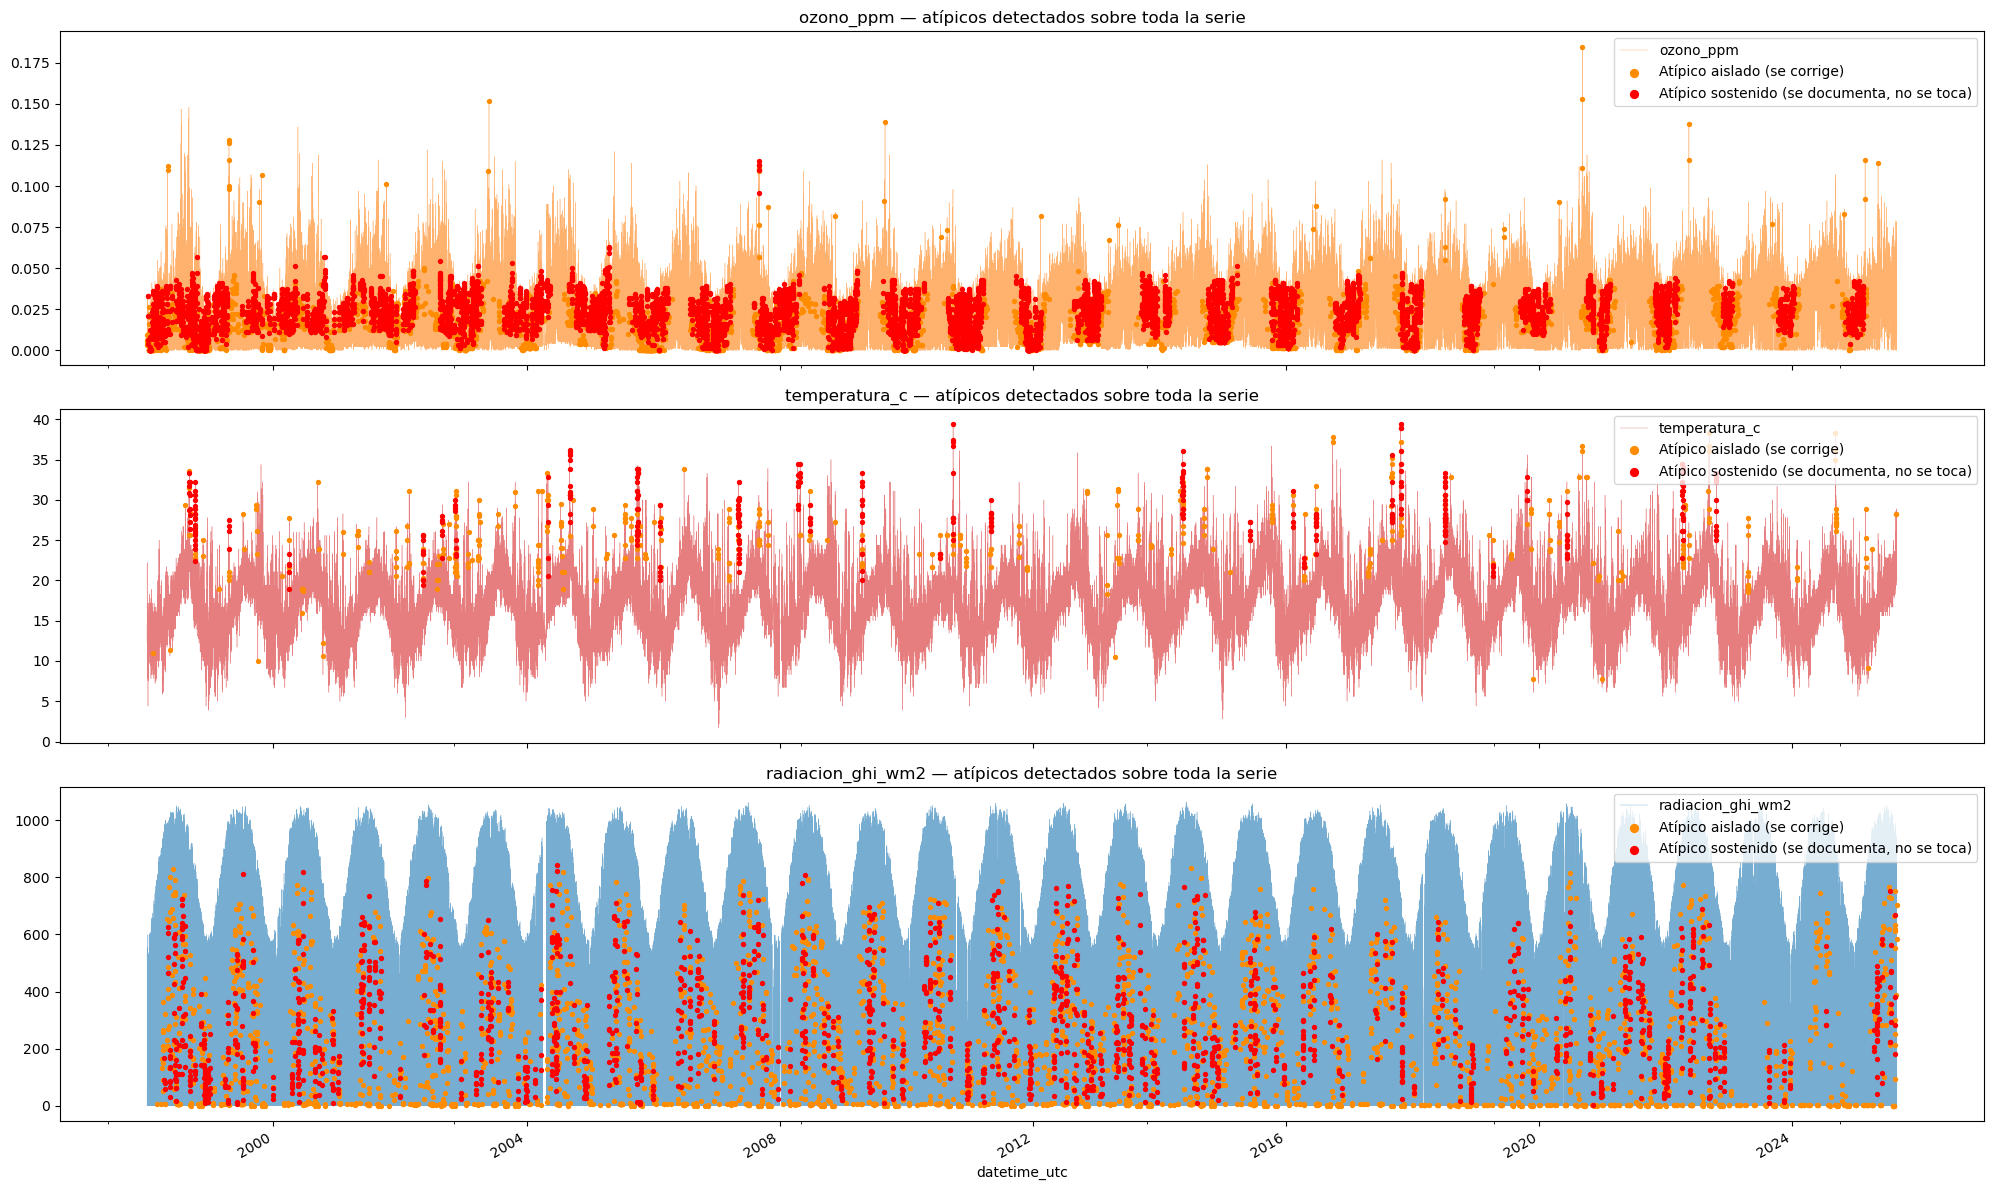

In [3]:
fig, axes = plt.subplots(len(datos.columns), 1, figsize=(20, 12), sharex=True)
for ax, col, color in zip(axes, datos.columns, ["tab:orange", "tab:red", "tab:blue"]):
    datos[col].plot(ax=ax, color=color, linewidth=0.3, alpha=0.6, label=col)
    sostenidas = atipicos_por_columna[col]["atipicos"] & ~atipicos_por_columna[col]["aisladas"]
    aisladas = atipicos_por_columna[col]["aisladas"]
    ax.scatter(datos.index[aisladas], datos.loc[aisladas, col], color="darkorange", s=8, zorder=3, label="Atípico aislado (se corrige)")
    ax.scatter(datos.index[sostenidas], datos.loc[sostenidas, col], color="red", s=8, zorder=3, label="Atípico sostenido (se documenta, no se toca)")
    ax.set_title(f"{col} — atípicos detectados sobre toda la serie")
    ax.legend(loc="upper right", markerscale=2)
plt.tight_layout()
plt.show()

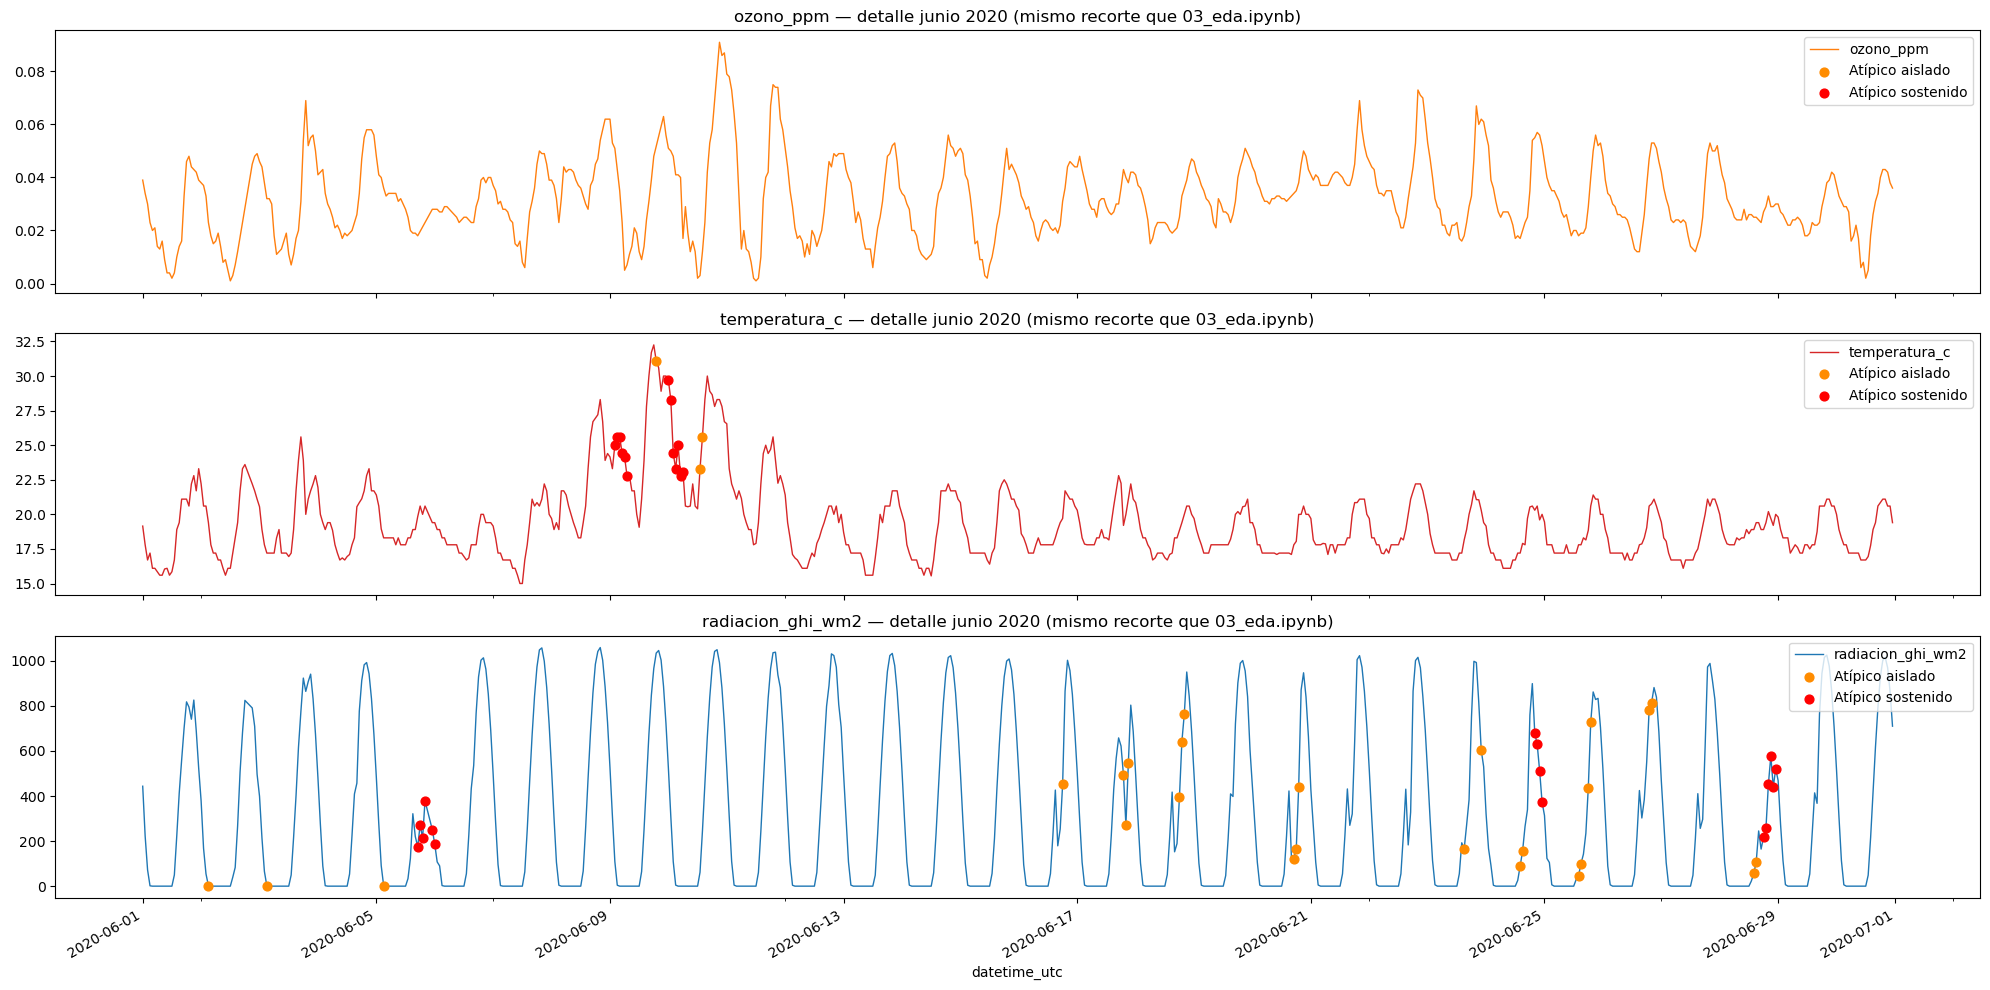

In [4]:
recorte = datos.loc["2020-06-01":"2020-06-30"]
fig, axes = plt.subplots(len(datos.columns), 1, figsize=(20, 10), sharex=True)
for ax, col, color in zip(axes, recorte.columns, ["tab:orange", "tab:red", "tab:blue"]):
    recorte[col].plot(ax=ax, color=color, linewidth=1, label=col)
    idx_recorte = recorte.index
    sostenidas = (atipicos_por_columna[col]["atipicos"] & ~atipicos_por_columna[col]["aisladas"]).reindex(idx_recorte, fill_value=False)
    aisladas = atipicos_por_columna[col]["aisladas"].reindex(idx_recorte, fill_value=False)
    ax.scatter(idx_recorte[aisladas], recorte.loc[aisladas, col], color="darkorange", s=40, zorder=3, label="Atípico aislado")
    ax.scatter(idx_recorte[sostenidas], recorte.loc[sostenidas, col], color="red", s=40, zorder=3, label="Atípico sostenido")
    ax.set_title(f"{col} — detalle junio 2020 (mismo recorte que 03_eda.ipynb)")
    ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 2. Tratamiento de atípicos aislados

Los atípicos aislados (≤3 horas seguidas) se anulan y se interpolan linealmente — misma técnica de suavizado que ya usa `02_limpieza.ipynb` para huecos cortos, aplicada ahora a valores puntuales sospechosos en lugar de a datos faltantes. Los sostenidos quedan intactos: una racha larga de ozono alto es más consistente con un episodio real de contaminación (o una ola de calor, en temperatura) que con un error de sensor, y "corregirlos" borraría información real de la serie.

In [5]:
datos_sin_atipicos = datos.copy()
for col in datos.columns:
    aisladas = atipicos_por_columna[col]["aisladas"]
    datos_sin_atipicos.loc[aisladas, col] = np.nan

print("Valores anulados por corrección de atípicos aislados (antes de interpolar):")
print(datos_sin_atipicos.isna().sum())

Valores anulados por corrección de atípicos aislados (antes de interpolar):
ozono_ppm            4027
temperatura_c         480
radiacion_ghi_wm2    3318
dtype: int64


## 3. Huecos en el índice temporal

`02_limpieza.ipynb` ya descarta huecos largos (>3h) y sólo deja pasar los cortos ya interpolados — pero eso dejó, de todas formas, ~48 horas/año de fechas completamente ausentes del índice (no NaN dentro de filas existentes, sino timestamps que no están). Esto no se ve con `isna().sum()` y fue la causa real de los bugs de `09_prophet_neuralprophet.ipynb` y `10_darts.ipynb` (documentados en `feedback_dl_libs_compat`): cada notebook que necesitaba una grilla horaria regular tenía que reindexar e interpolar por su cuenta. Se resuelve acá una única vez para todo el resto del TP2.

In [6]:
indice_completo = pd.date_range(datos_sin_atipicos.index.min(), datos_sin_atipicos.index.max(), freq="h")
fechas_faltantes = indice_completo.difference(datos_sin_atipicos.index)
huecos = len(fechas_faltantes)
print(f"Índice actual: {len(datos_sin_atipicos):,} filas | Índice regular esperado: {len(indice_completo):,} filas | Huecos: {huecos} ({100*huecos/len(indice_completo):.3f}%)")

Índice actual: 239,078 filas | Índice regular esperado: 242,402 filas | Huecos: 3324 (1.371%)


### Visualización de los huecos temporales por año

Estas fechas están directamente ausentes del índice (no son NaN dentro de una fila existente), así que no se pueden graficar como puntos sobre la serie — se cuentan por año para ver en qué períodos se concentra la peor calidad de datos de origen.

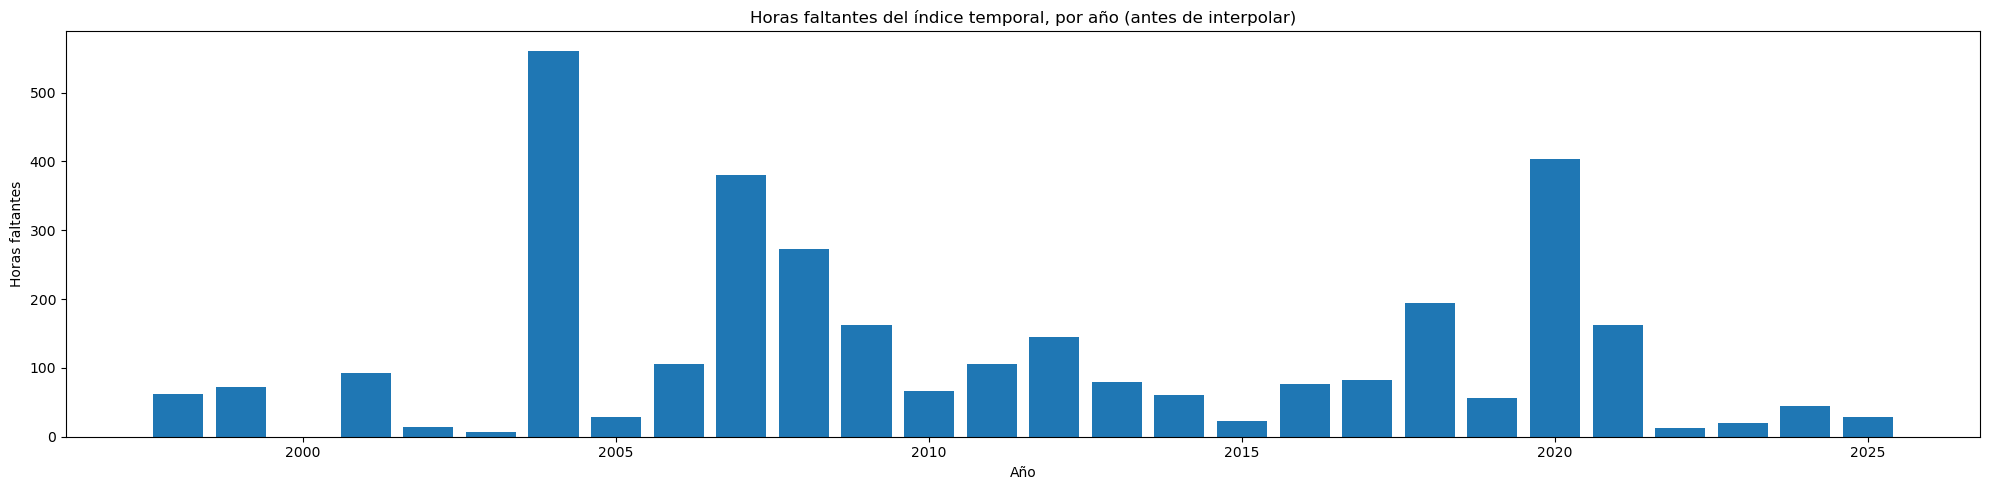

In [7]:
huecos_por_anio = fechas_faltantes.year.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(20, 5))
ax.bar(huecos_por_anio.index, huecos_por_anio.values, color="tab:blue")
ax.set_title("Horas faltantes del índice temporal, por año (antes de interpolar)")
ax.set_xlabel("Año")
ax.set_ylabel("Horas faltantes")
plt.tight_layout()
plt.show()

In [8]:
datos_tratados = datos_sin_atipicos.reindex(indice_completo).interpolate("linear").bfill()
print(f"Dataset tratado: {len(datos_tratados):,} filas, índice regular, sin NaN.")
print(datos_tratados.isna().sum())

Dataset tratado: 242,402 filas, índice regular, sin NaN.
ozono_ppm            0
temperatura_c        0
radiacion_ghi_wm2    0
dtype: int64


### Antes / después del tratamiento

Mismos dos gráficos de la sección 1, pero sobre `datos_tratados`: los atípicos aislados (naranja) ahora deberían verse pegados a la línea (ya fueron interpolados), mientras que los sostenidos (rojo) siguen sobresaliendo — a propósito, porque no se tocaron.

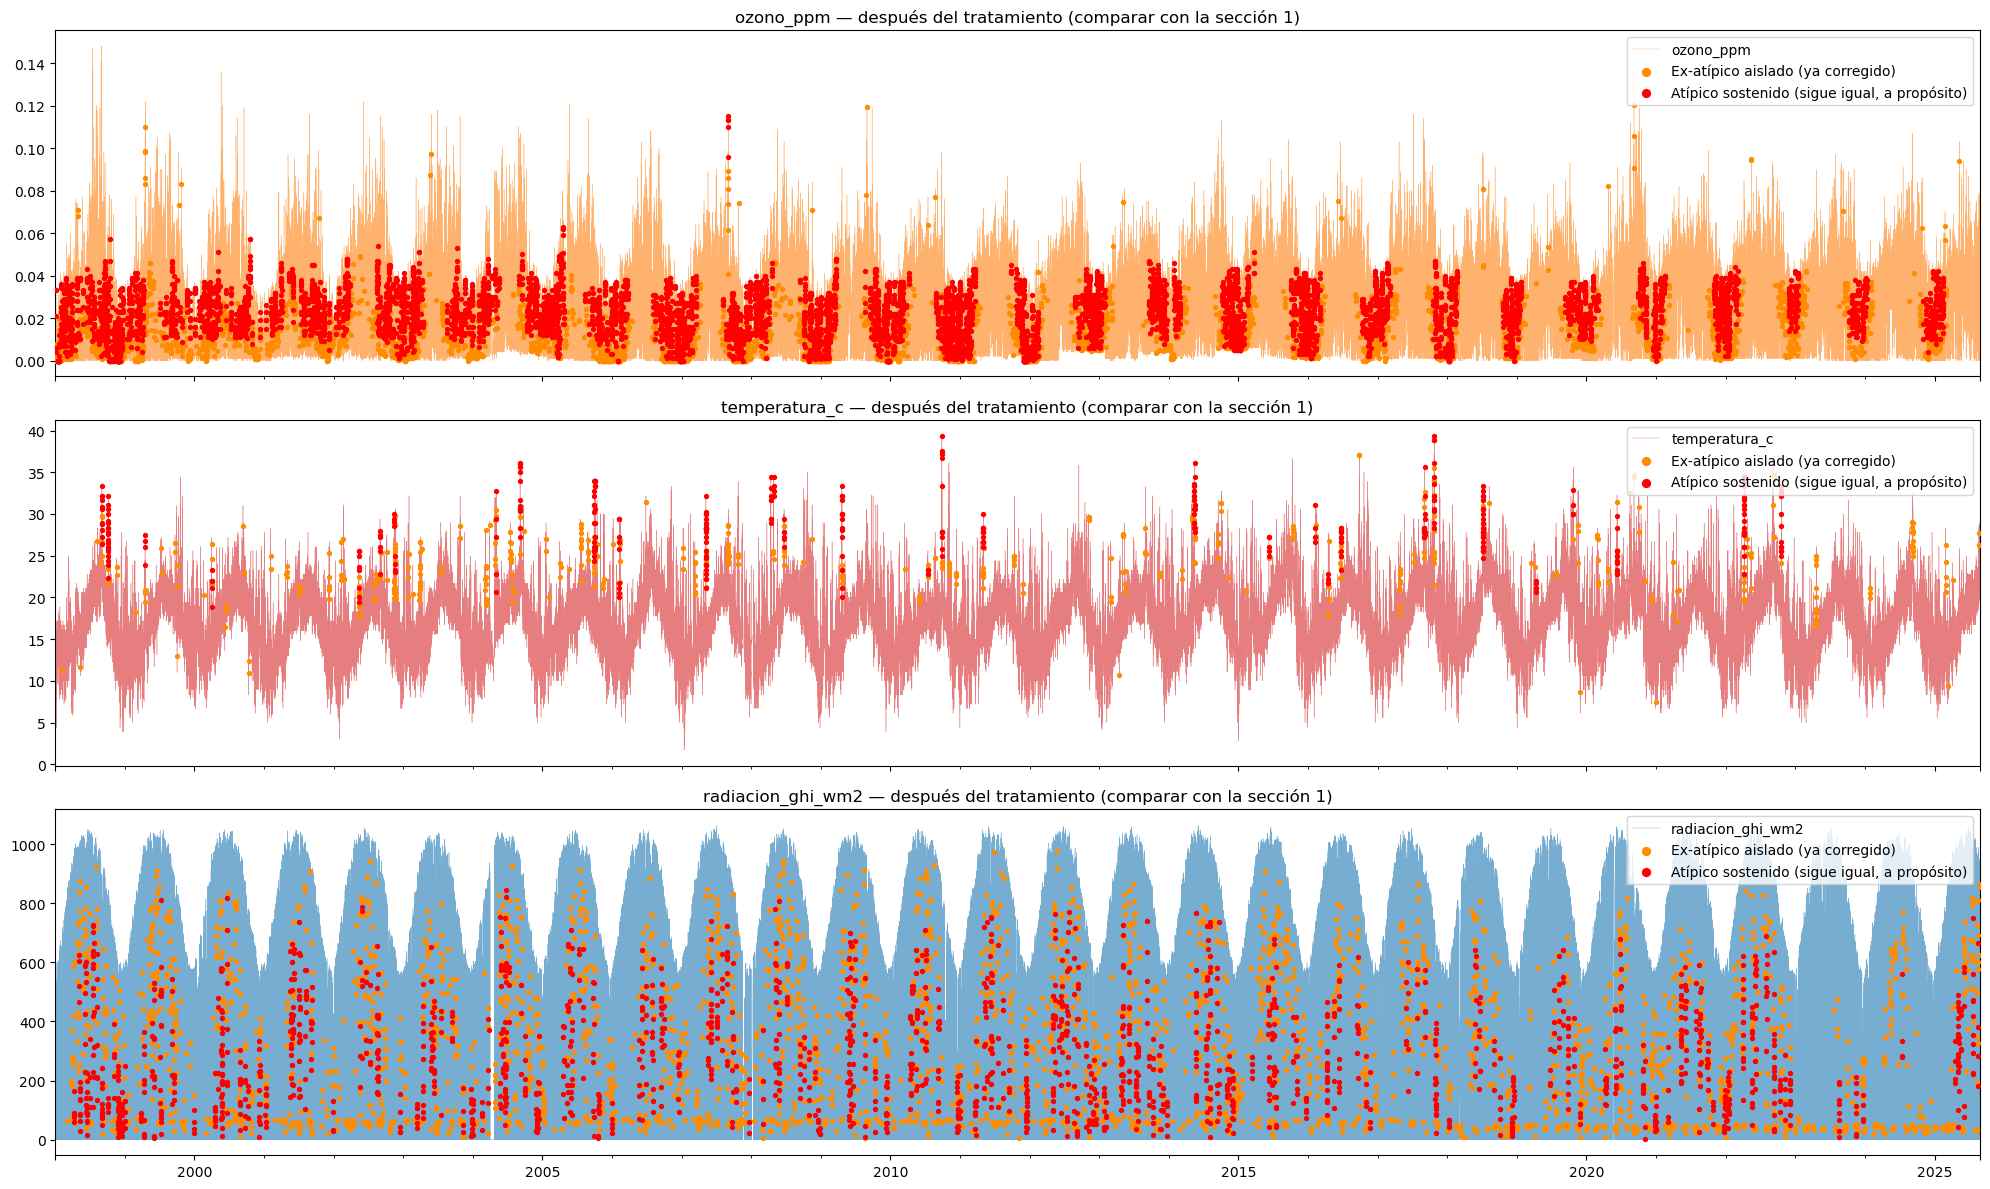

In [9]:
fig, axes = plt.subplots(len(datos.columns), 1, figsize=(20, 12), sharex=True)
for ax, col, color in zip(axes, datos_tratados.columns, ["tab:orange", "tab:red", "tab:blue"]):
    datos_tratados[col].plot(ax=ax, color=color, linewidth=0.3, alpha=0.6, label=col)
    sostenidas = (atipicos_por_columna[col]["atipicos"] & ~atipicos_por_columna[col]["aisladas"]).reindex(datos_tratados.index, fill_value=False)
    aisladas = atipicos_por_columna[col]["aisladas"].reindex(datos_tratados.index, fill_value=False)
    ax.scatter(datos_tratados.index[aisladas], datos_tratados.loc[aisladas, col], color="darkorange", s=8, zorder=3, label="Ex-atípico aislado (ya corregido)")
    ax.scatter(datos_tratados.index[sostenidas], datos_tratados.loc[sostenidas, col], color="red", s=8, zorder=3, label="Atípico sostenido (sigue igual, a propósito)")
    ax.set_title(f"{col} — después del tratamiento (comparar con la sección 1)")
    ax.legend(loc="upper right", markerscale=2)
plt.tight_layout()
plt.show()

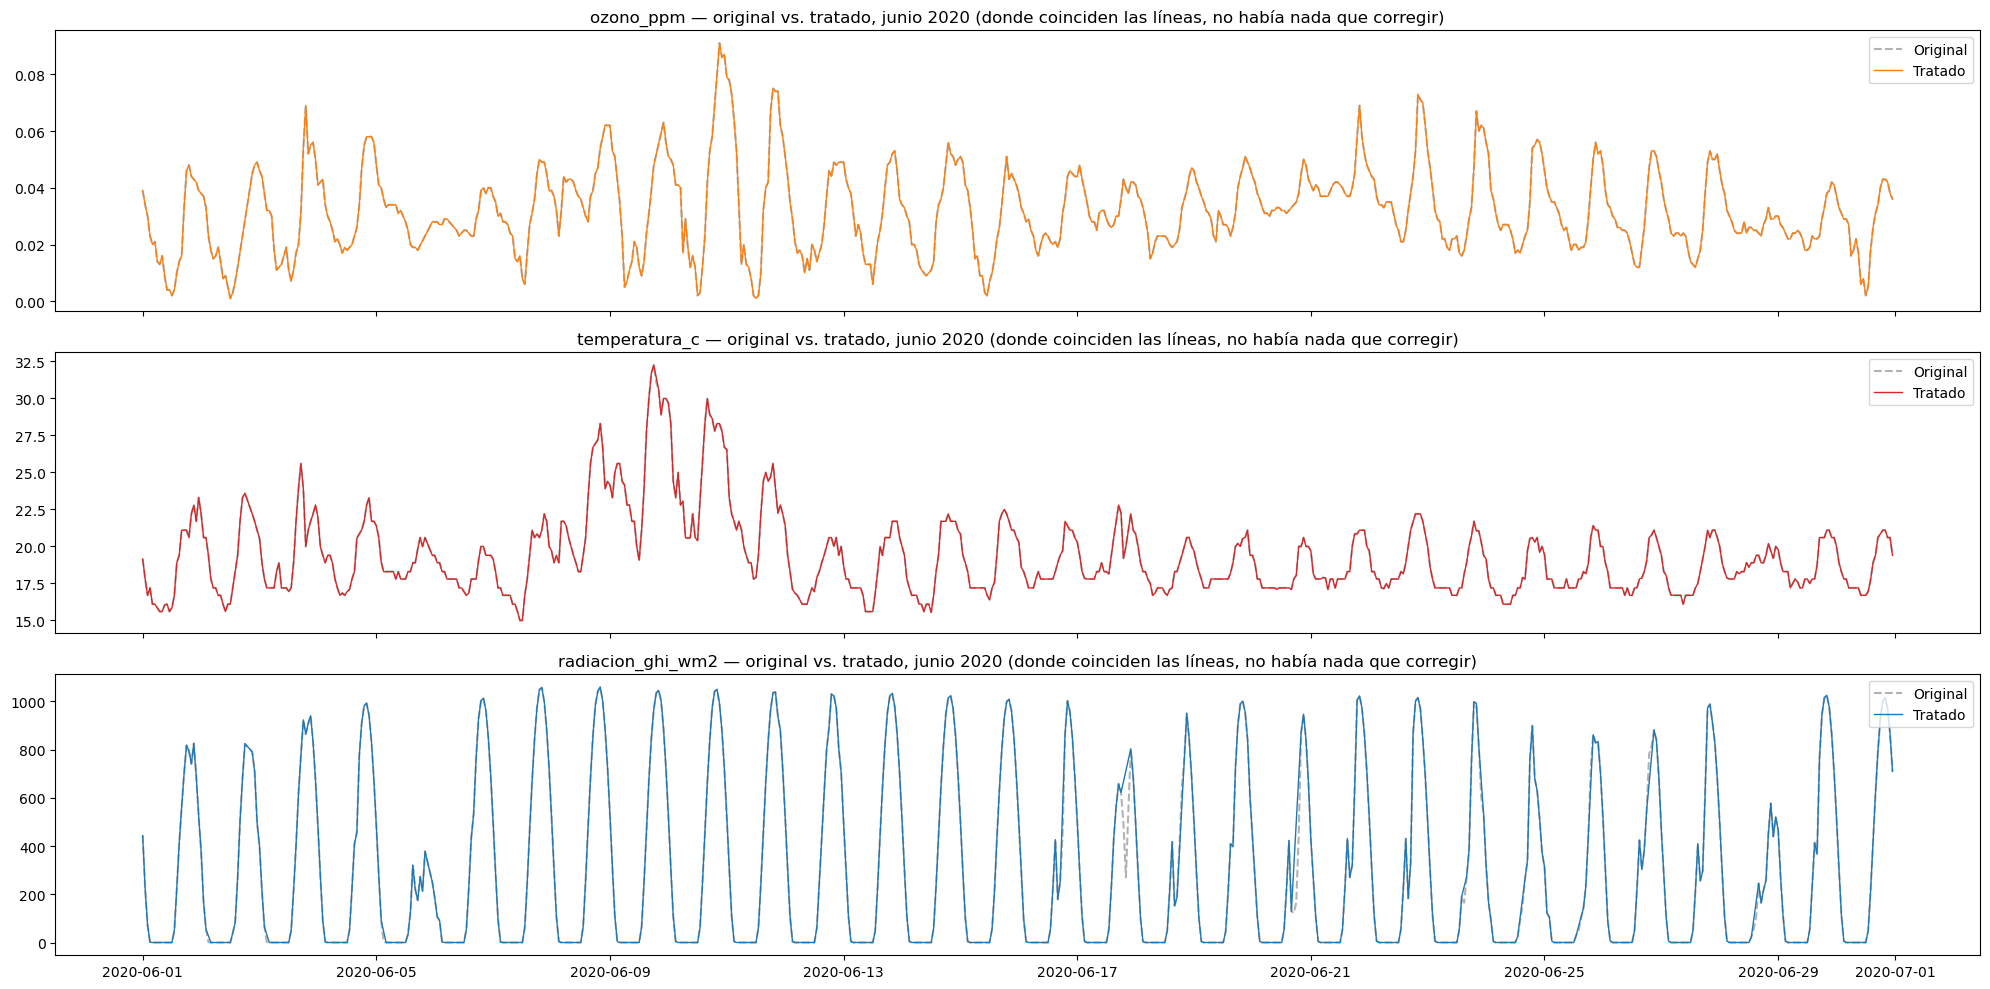

In [10]:
recorte_antes = datos.loc["2020-06-01":"2020-06-30"]
recorte_despues = datos_tratados.loc["2020-06-01":"2020-06-30"]
fig, axes = plt.subplots(len(datos.columns), 1, figsize=(20, 10), sharex=True)
for ax, col, color in zip(axes, recorte_antes.columns, ["tab:orange", "tab:red", "tab:blue"]):
    ax.plot(recorte_antes.index, recorte_antes[col], color="gray", linewidth=1.5, linestyle="--", alpha=0.6, label="Original")
    ax.plot(recorte_despues.index, recorte_despues[col], color=color, linewidth=1, label="Tratado")
    ax.set_title(f"{col} — original vs. tratado, junio 2020 (donde coinciden las líneas, no había nada que corregir)")
    ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 4. Modelo de espacio de estados (`UnobservedComponents`)

SARIMAX (`05_sarima.ipynb`) ya es, por dentro, un modelo de espacio de estados (usa el filtro de Kalman), pero nunca se lo presentó ni se lo comparó como tal. `UnobservedComponents` lo hace explícito: descompone la serie en **nivel local** (una tendencia que puede moverse con el tiempo, a diferencia de una tendencia fija) + **estacional** (ciclo diario, período 24) como componentes separados y estimables. Se prueba sobre la misma ventana de 1 año y holdout de 168 horas que el resto del TP2, con el dataset ya tratado.

In [11]:
import time
from statsmodels.tsa.statespace.structural import UnobservedComponents

HORAS_TEST = 24 * 7
VENTANA_DIAS_MODELADO = 365
resultados_espacio_estados = {}

for col in datos_tratados.columns:
    serie = datos_tratados[col].iloc[-(VENTANA_DIAS_MODELADO * 24):]
    train, test = serie.iloc[:-HORAS_TEST], serie.iloc[-HORAS_TEST:]

    t0 = time.time()
    modelo = UnobservedComponents(train.values, level="local level", seasonal=24)
    ajuste = modelo.fit(disp=False, maxiter=50)
    pred = ajuste.forecast(HORAS_TEST)

    mae = mean_absolute_error(test.values, pred)
    rmse = mean_squared_error(test.values, pred) ** 0.5
    resultados_espacio_estados.setdefault(col, {})["UnobservedComponents"] = {
        "MAE": mae, "RMSE": rmse,
        "_test_real": test.values.tolist(), "_test_pred": pred.tolist(),
    }
    print(f"[UnobservedComponents - {col}] MAE={mae:.5f}  RMSE={rmse:.5f}  ({time.time() - t0:.1f}s)")

[UnobservedComponents - ozono_ppm] MAE=0.01599  RMSE=0.01972  (4.7s)


[UnobservedComponents - temperatura_c] MAE=1.17946  RMSE=1.52927  (5.5s)


[UnobservedComponents - radiacion_ghi_wm2] MAE=84.14410  RMSE=114.77692  (5.5s)


## 5. Suavizado exponencial como modelo de espacio de estados (`ETSModel`)

`10_darts.ipynb` ya usó `ExponentialSmoothing`, pero como una "librería más" sin explicar qué hay detrás. `statsmodels.tsa.exponential_smoothing.ets.ETSModel` es la formulación explícita en espacio de estados del suavizado exponencial (de ahí la sigla ETS: Error-Tendencia-Estacionalidad) — mismo tipo de modelo, presentado con su interpretación formal de espacio de estados en vez de como una caja negra.

In [12]:
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

for col in datos_tratados.columns:
    serie = datos_tratados[col].iloc[-(VENTANA_DIAS_MODELADO * 24):]
    train, test = serie.iloc[:-HORAS_TEST], serie.iloc[-HORAS_TEST:]

    t0 = time.time()
    modelo = ETSModel(train, error="add", trend=None, seasonal="add", seasonal_periods=24)
    ajuste = modelo.fit(disp=False)
    pred = ajuste.forecast(HORAS_TEST)

    mae = mean_absolute_error(test.values, pred.values)
    rmse = mean_squared_error(test.values, pred.values) ** 0.5
    resultados_espacio_estados.setdefault(col, {})["ETSModel"] = {
        "MAE": mae, "RMSE": rmse,
        "_test_real": test.values.tolist(), "_test_pred": pred.values.tolist(),
    }
    print(f"[ETSModel - {col}] MAE={mae:.5f}  RMSE={rmse:.5f}  ({time.time() - t0:.1f}s)")

[ETSModel - ozono_ppm] MAE=0.01624  RMSE=0.01998  (3.2s)


[ETSModel - temperatura_c] MAE=1.08952  RMSE=1.35859  (2.8s)


[ETSModel - radiacion_ghi_wm2] MAE=71.75017  RMSE=91.45284  (1.7s)


## 6. Diagnóstico: ¿los residuos son ruido blanco?

`05_sarima.ipynb` ya había corrido Ljung-Box sobre los residuos de SARIMA (dio que NO son ruido blanco — autocorrelación remanente, limitación ya documentada), pero ese chequeo nunca se repitió para los modelos nuevos. Se aplica acá a los dos modelos de esta sección, y sirve de plantilla para que `13_sintesis_final.ipynb` lo repita sobre el modelo ganador de cada serie.

In [13]:
from statsmodels.stats.diagnostic import acorr_ljungbox

for col in datos_tratados.columns:
    for nombre_modelo in ["UnobservedComponents", "ETSModel"]:
        real = np.array(resultados_espacio_estados[col][nombre_modelo]["_test_real"])
        pred = np.array(resultados_espacio_estados[col][nombre_modelo]["_test_pred"])
        residuos = real - pred
        lb = acorr_ljungbox(residuos, lags=[24], return_df=True)
        p_valor = lb["lb_pvalue"].iloc[0]
        es_ruido_blanco = p_valor > 0.05
        resultados_espacio_estados[col][nombre_modelo]["ljung_box_p"] = float(p_valor)
        resultados_espacio_estados[col][nombre_modelo]["es_ruido_blanco"] = bool(es_ruido_blanco)
        veredicto = "SÍ (sin autocorrelación remanente)" if es_ruido_blanco else "NO (queda estructura sin capturar)"
        print(f"{col} / {nombre_modelo}: Ljung-Box p={p_valor:.4f} -> ¿residuos son ruido blanco? {veredicto}")

ozono_ppm / UnobservedComponents: Ljung-Box p=0.0000 -> ¿residuos son ruido blanco? NO (queda estructura sin capturar)
ozono_ppm / ETSModel: Ljung-Box p=0.0000 -> ¿residuos son ruido blanco? NO (queda estructura sin capturar)
temperatura_c / UnobservedComponents: Ljung-Box p=0.0000 -> ¿residuos son ruido blanco? NO (queda estructura sin capturar)
temperatura_c / ETSModel: Ljung-Box p=0.0000 -> ¿residuos son ruido blanco? NO (queda estructura sin capturar)
radiacion_ghi_wm2 / UnobservedComponents: Ljung-Box p=0.0000 -> ¿residuos son ruido blanco? NO (queda estructura sin capturar)
radiacion_ghi_wm2 / ETSModel: Ljung-Box p=0.0000 -> ¿residuos son ruido blanco? NO (queda estructura sin capturar)


## 7. Pronósticos graficados

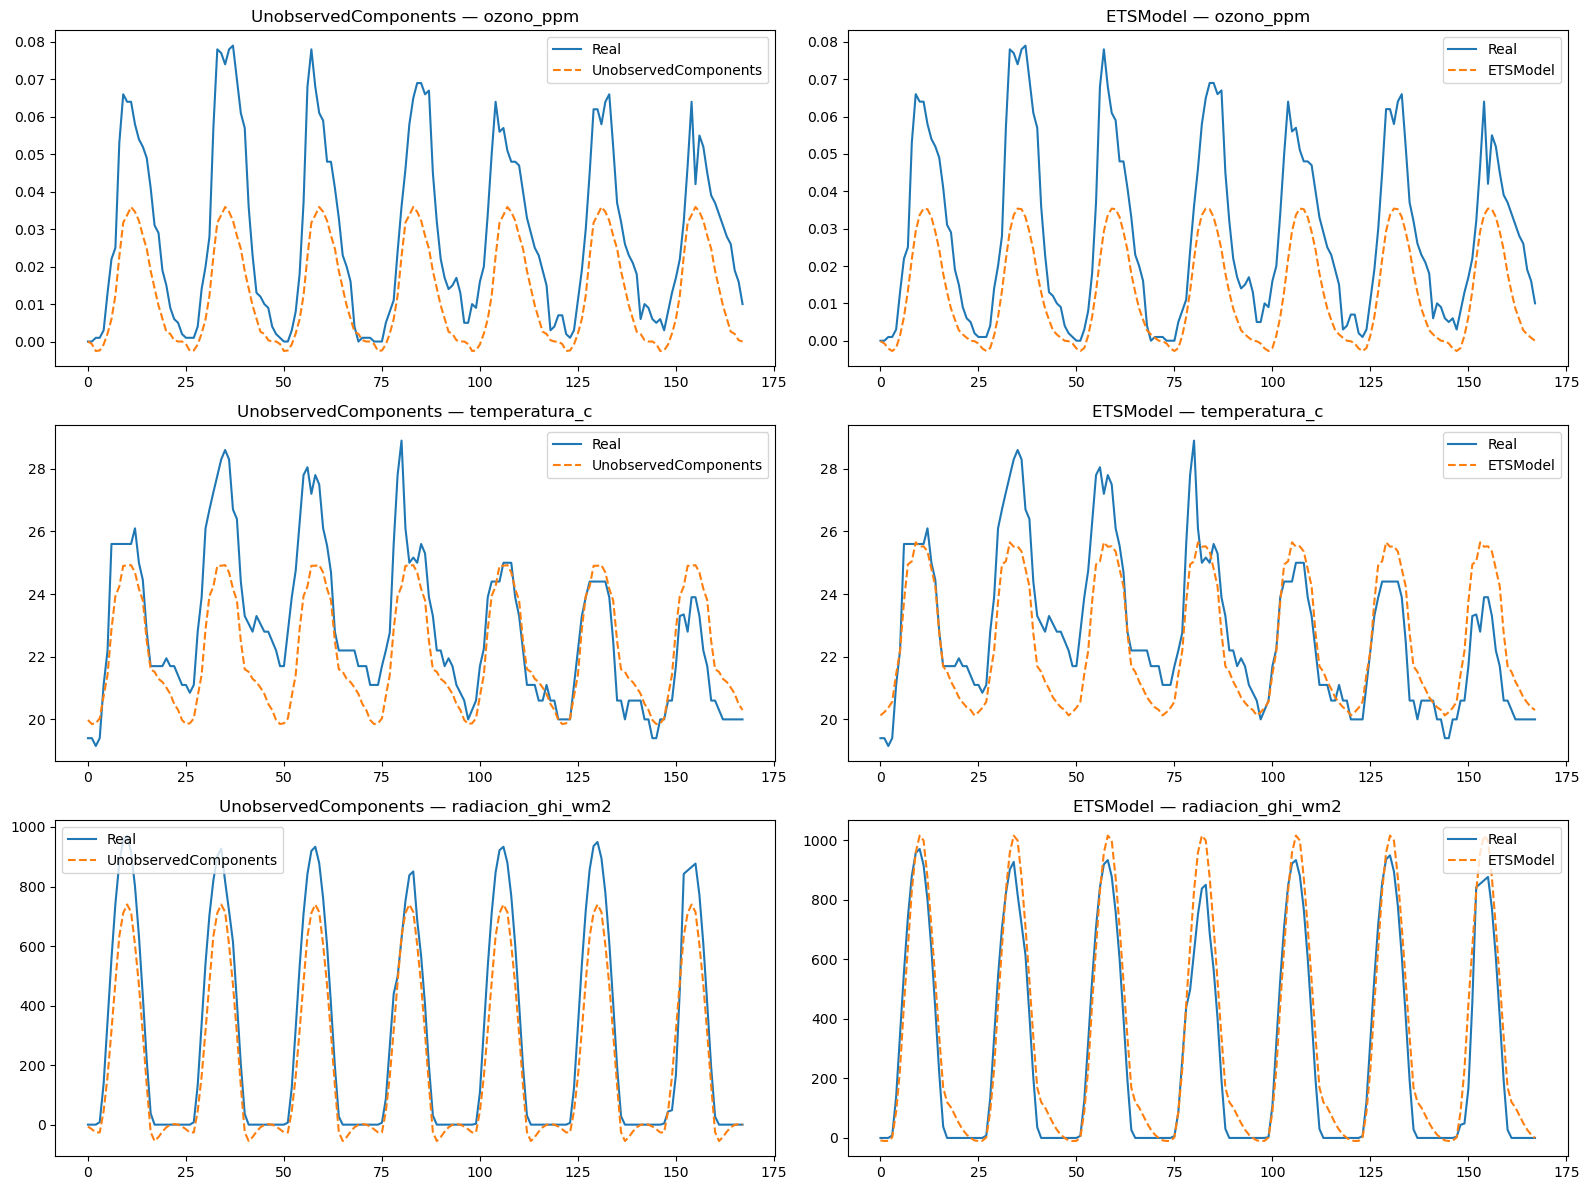

In [14]:
fig, axes = plt.subplots(len(datos_tratados.columns), 2, figsize=(16, 12))

for fila, col in enumerate(datos_tratados.columns):
    for columna_ax, nombre_modelo in enumerate(["UnobservedComponents", "ETSModel"]):
        r = resultados_espacio_estados[col][nombre_modelo]
        axes[fila, columna_ax].plot(r["_test_real"], label="Real")
        axes[fila, columna_ax].plot(r["_test_pred"], label=nombre_modelo, linestyle="--")
        axes[fila, columna_ax].set_title(f"{nombre_modelo} — {col}")
        axes[fila, columna_ax].legend()

plt.tight_layout()
plt.show()

## 8. Guardado: dataset tratado y resultados

In [15]:
destino_dataset = PROJECT_ROOT / "data/processed/serie_california_tratada.csv"
datos_tratados.to_csv(destino_dataset, index_label="datetime_utc")
print(f"Dataset tratado guardado en {destino_dataset} ({len(datos_tratados):,} filas)")

def limpiar(resultados):
    return {
        col: {modelo: {k: v for k, v in r.items() if not k.startswith("_")} for modelo, r in modelos.items()}
        for col, modelos in resultados.items()
    }

destino_resultados = PROJECT_ROOT / "data/processed/resultados_espacio_estados.json"
destino_resultados.write_text(json.dumps(limpiar(resultados_espacio_estados), indent=2), encoding="utf-8")

print(json.dumps(limpiar(resultados_espacio_estados), indent=2))
print(f"\nGuardado en {destino_resultados}")
print("\nA partir de acá, 08_lstm.ipynb en adelante debe leer 'serie_california_tratada.csv' en vez de 'serie_california.csv'.")

Dataset tratado guardado en C:\Series_AMBA\data\processed\serie_california_tratada.csv (242,402 filas)
{
  "ozono_ppm": {
    "UnobservedComponents": {
      "MAE": 0.01598768855847262,
      "RMSE": 0.01972354373743462,
      "ljung_box_p": 3.292818424433384e-148,
      "es_ruido_blanco": false
    },
    "ETSModel": {
      "MAE": 0.016241615718956545,
      "RMSE": 0.019975546472859273,
      "ljung_box_p": 1.7561872134315838e-146,
      "es_ruido_blanco": false
    }
  },
  "temperatura_c": {
    "UnobservedComponents": {
      "MAE": 1.1794556781177177,
      "RMSE": 1.5292728178608104,
      "ljung_box_p": 9.158777918882909e-288,
      "es_ruido_blanco": false
    },
    "ETSModel": {
      "MAE": 1.0895230475419329,
      "RMSE": 1.3585903608739267,
      "ljung_box_p": 0.0,
      "es_ruido_blanco": false
    }
  },
  "radiacion_ghi_wm2": {
    "UnobservedComponents": {
      "MAE": 84.1440982009503,
      "RMSE": 114.77691730853469,
      "ljung_box_p": 1.4047770840548418e-146,